## Exploratory Data Analysis


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

#### Loading processed data set


In [3]:
df = pd.read_csv("../data/processed/hotel_bookings_final.csv")

In [4]:
df["reservation_status_date"] = pd.to_datetime(
    df["reservation_status_date"]
)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 42 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119390 non-null  int64  

In [6]:
print("Shape:", df.shape)

df.head()

Shape: (119390, 42)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay,total_guests,estimated_revenue,season,family_booking,lead_time_category,booking_status,guest_type,arrival_quarter,long_stay
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,Not Applicable,Not Applicable,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2,0.0,Summer,No,Long,Completed,Couple,Q3,No
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,Not Applicable,Not Applicable,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2,0.0,Summer,No,Long,Completed,Couple,Q3,No
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,Not Applicable,Not Applicable,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,75.0,Summer,No,Short,Completed,Solo,Q3,No
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,Not Applicable,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,75.0,Summer,No,Short,Completed,Solo,Q3,No
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,Not Applicable,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2,196.0,Summer,No,Short,Completed,Couple,Q3,No


### Analysis 1: Hotel Booking Distribution
 Question

Which hotel receives more bookings?

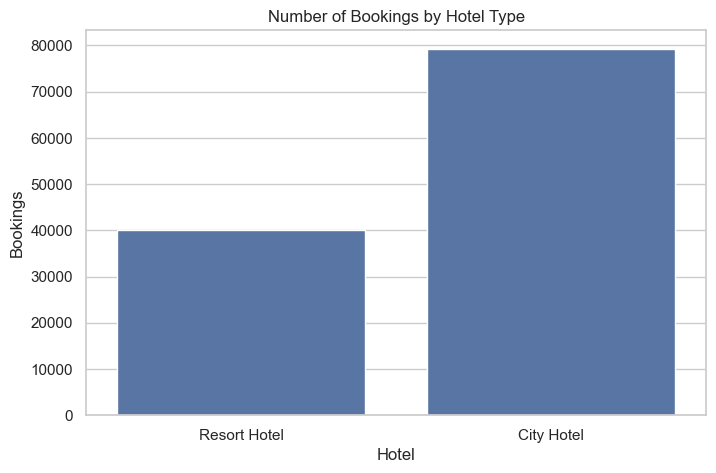

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="hotel"
)

plt.title("Number of Bookings by Hotel Type")
plt.xlabel("Hotel")
plt.ylabel("Bookings")

plt.show()

### Insight

Compare the booking volume between City Hotel and Resort Hotel.
This helps identify which hotel type experiences higher tourism demand.

### Analysis 2: Monthly Tourism Demand
Question

Which months have the highest tourism demand?

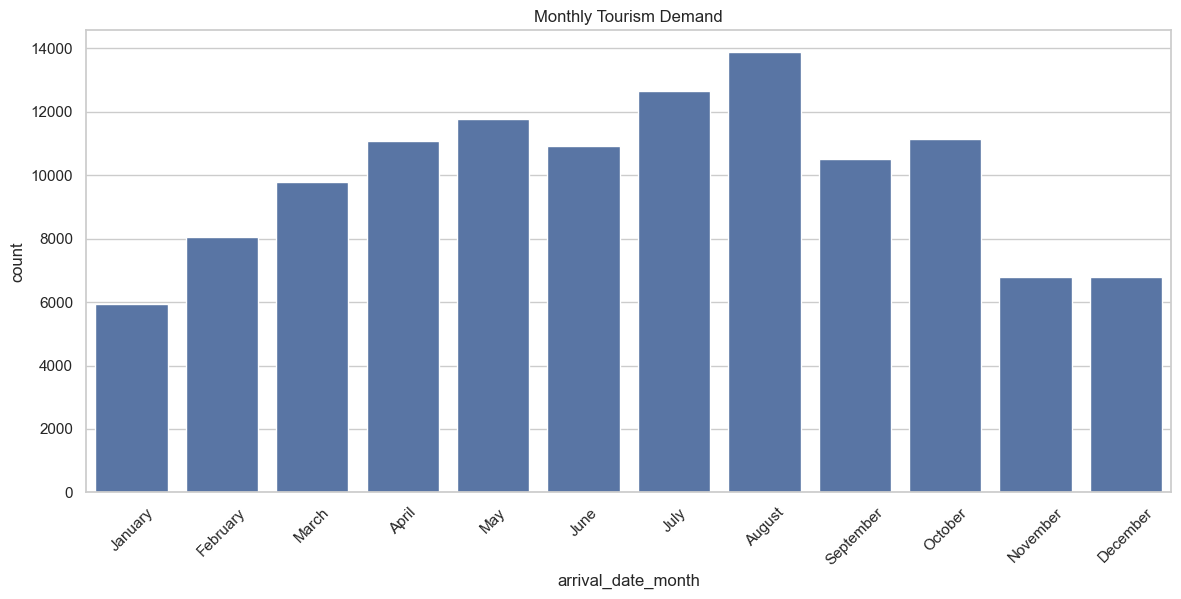

In [8]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x="arrival_date_month",
    order=month_order
)

plt.xticks(rotation=45)

plt.title("Monthly Tourism Demand")

plt.show()

### Insight

Identify peak tourism months and low-demand periods.
Useful for seasonal planning and marketing campaigns.

### Analysis 3: Booking Status
Question

What percentage of bookings are completed versus canceled?

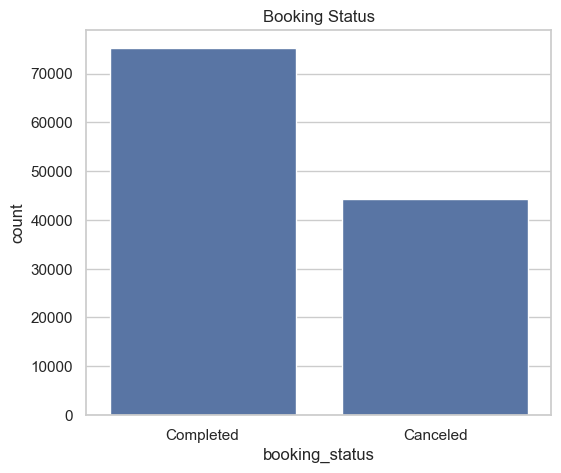

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="booking_status"
)

plt.title("Booking Status")

plt.show()

### Insight

Analyze cancellation patterns.
A high cancellation rate may indicate opportunities to improve booking policies.

### Analysis 4: Top 10 Visitor Countries
Question

Which countries contribute the most bookings?

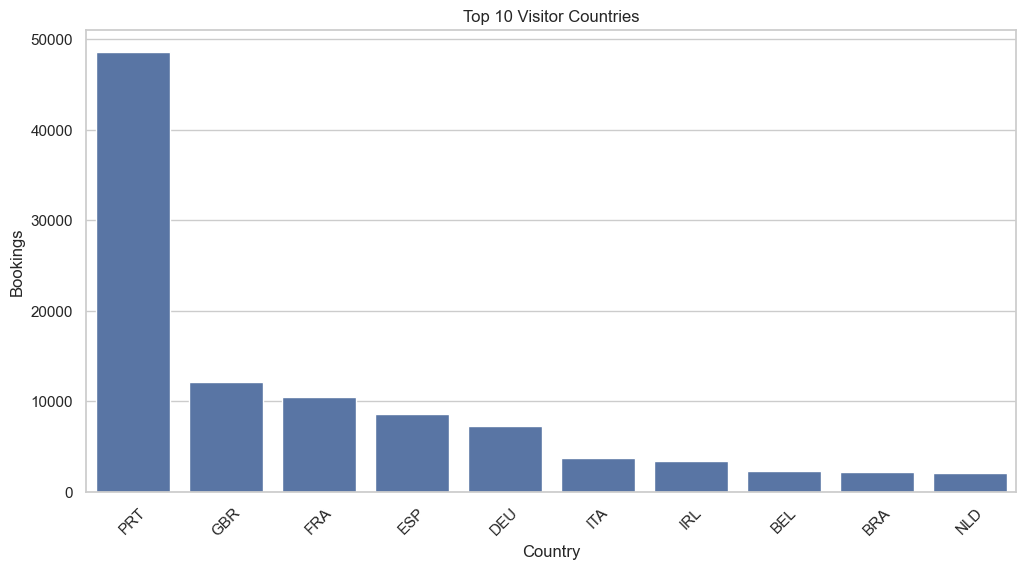

In [10]:
top_countries = (
    df["country"]
      .value_counts()
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Visitor Countries")

plt.xlabel("Country")

plt.ylabel("Bookings")

plt.show()

### Insight

Identify the largest source markets.
These countries are potential targets for tourism marketing.

### Analysis 5: Estimated Revenue by Hotel
Question

Which hotel generates more estimated revenue?

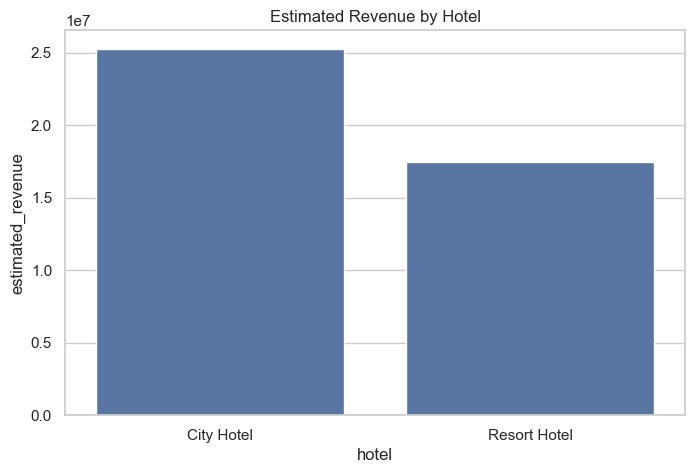

In [11]:
hotel_revenue = (
    df.groupby("hotel")["estimated_revenue"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=hotel_revenue,
    x="hotel",
    y="estimated_revenue"
)

plt.title("Estimated Revenue by Hotel")

plt.show()

### Insight

Compare estimated revenue between hotel types.
Higher revenue may indicate stronger business performance.

### Analysis 6: Average Stay by Hotel Type
Question

Which hotel has longer average guest stays?

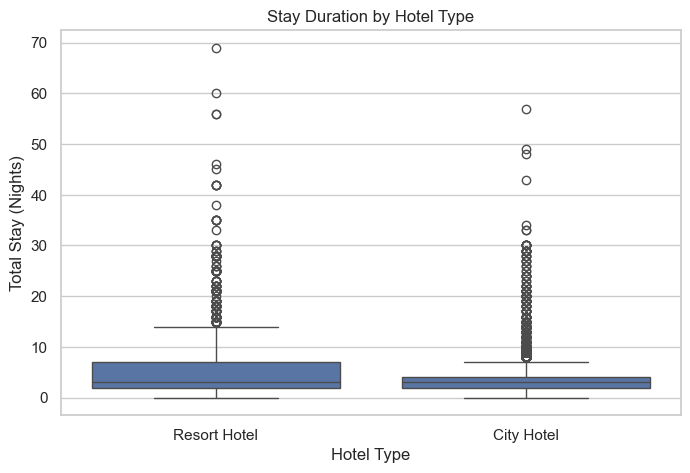

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="hotel",
    y="total_stay"
)

plt.title("Stay Duration by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Total Stay (Nights)")

plt.show()

###  Insight

Compare stay duration between City Hotel and Resort Hotel.
Longer stays can indicate higher customer value and revenue potential.

### Analysis 7: Estimated Revenue by Season
Question

Which season generates the highest estimated revenue?

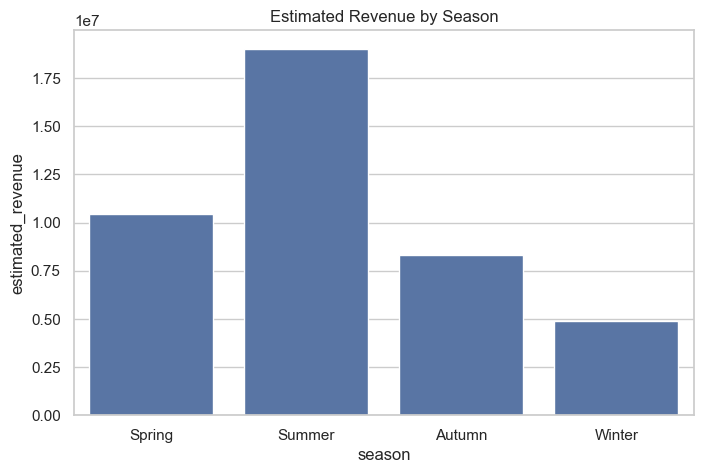

In [13]:
season_revenue = (
    df.groupby("season")["estimated_revenue"]
      .sum()
      .reset_index()
)

season_order = ["Spring", "Summer", "Autumn", "Winter"]

plt.figure(figsize=(8,5))

sns.barplot(
    data=season_revenue,
    x="season",
    y="estimated_revenue",
    order=season_order
)

plt.title("Estimated Revenue by Season")

plt.show()

###  Insight

Identify the most profitable season to support pricing and marketing decisions.

### Analysis 8: Market Segment Distribution
Question

Which customer segments contribute the most bookings?

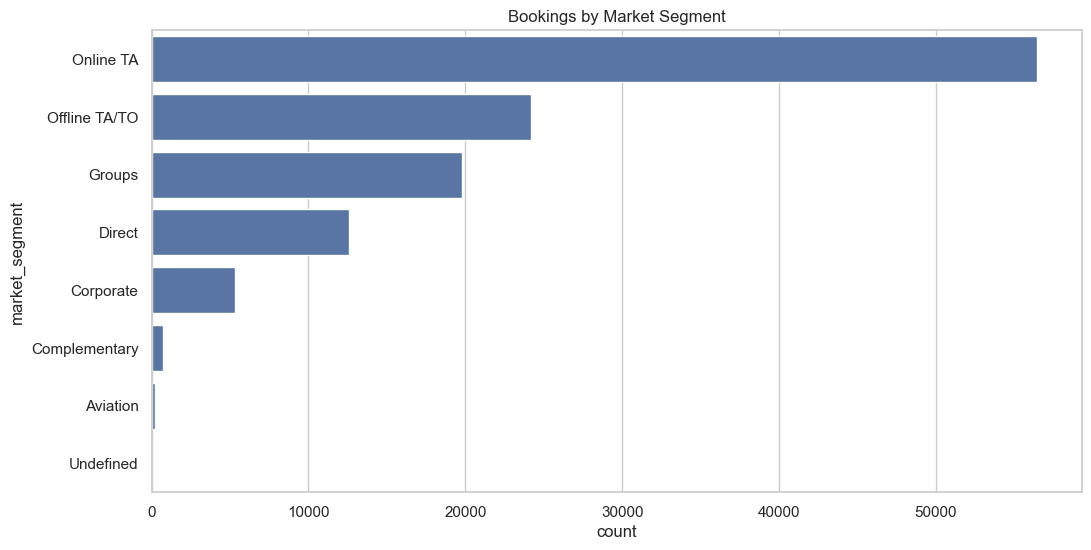

In [14]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="market_segment",
    order=df["market_segment"].value_counts().index
)

plt.title("Bookings by Market Segment")

plt.show()

###  Insight

Identify the dominant market segments and prioritize marketing efforts accordingly.

### Analysis 9: Booking Lead Time Category
Question

Do customers book early or at the last minute?

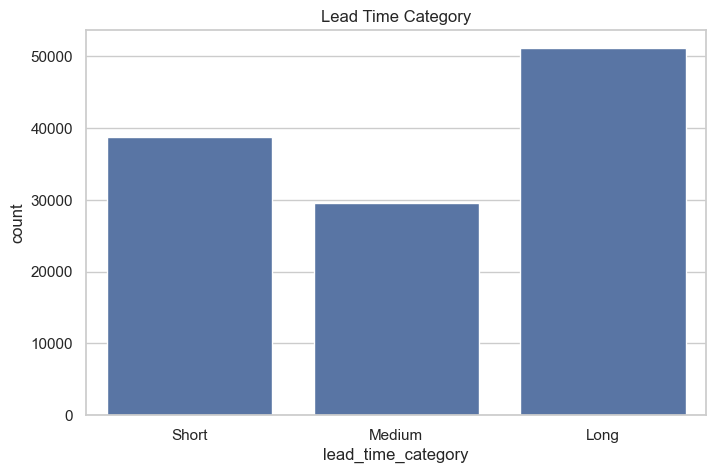

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="lead_time_category",
    order=["Short","Medium","Long"]
)

plt.title("Lead Time Category")

plt.show()

###  Insight

Understanding booking behavior helps optimize promotions and pricing strategies.

### Analysis 10: Family vs Non-Family Bookings
Question

What proportion of bookings are family bookings?

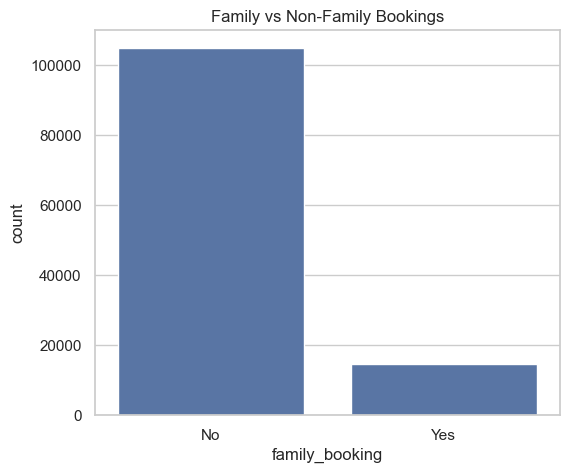

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="family_booking"
)

plt.title("Family vs Non-Family Bookings")

plt.show()

###  Insight

Measure the proportion of family travelers to guide service and package planning.

### Analysis 11: Guest Type Distribution
Question

Which type of traveler books most frequently?

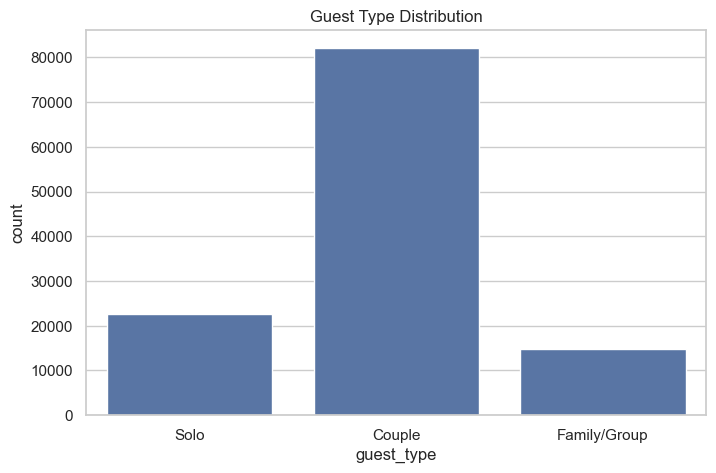

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="guest_type",
    order=["Solo","Couple","Family/Group"]
)

plt.title("Guest Type Distribution")

plt.show()

### Insight

Identify whether solo travelers, couples, or families make the majority of bookings.

### Analysis 12: ADR Distribution
Question

How are room prices distributed?

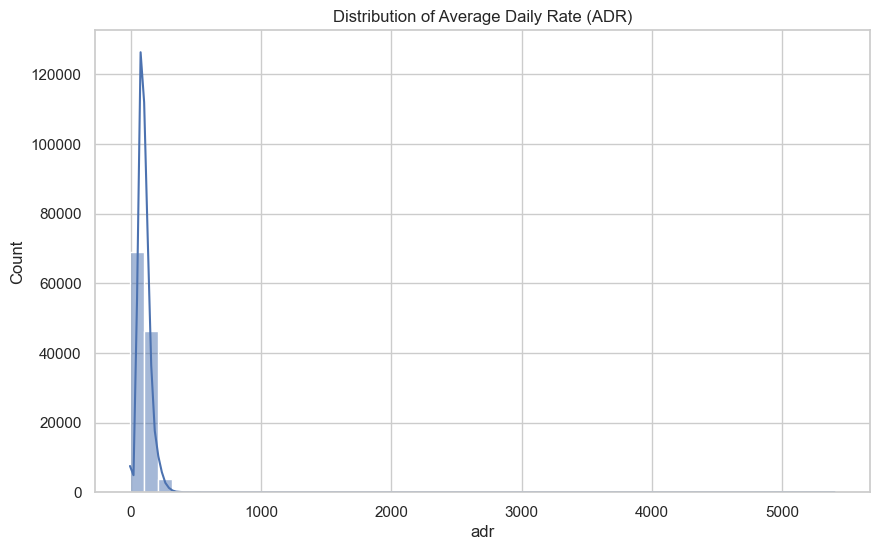

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="adr",
    bins=50,
    kde=True
)

plt.title("Distribution of Average Daily Rate (ADR)")

plt.show()

### Insight

Understand pricing patterns and identify unusually high or low room rates.

### Analysis 13: Correlation Heatmap
Question

Which numerical variables are related?

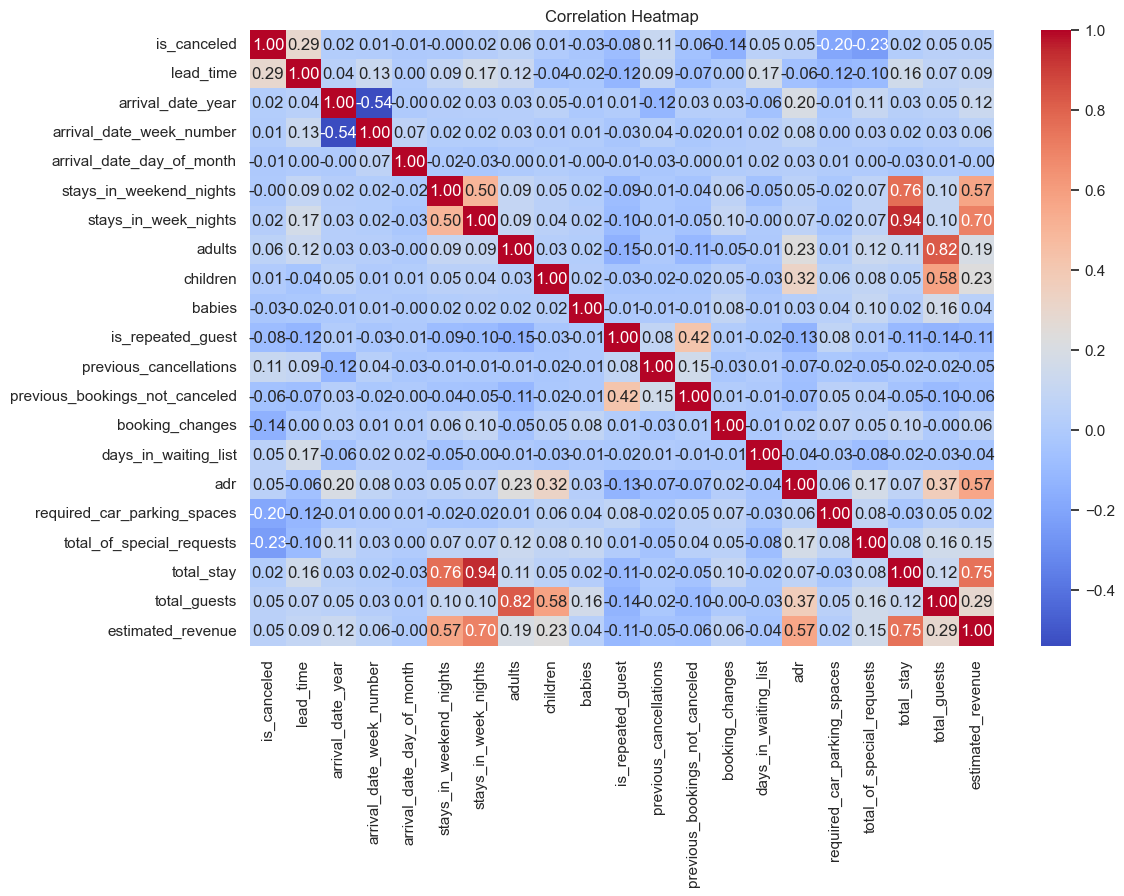

In [19]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=["int64","float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Insight

Correlation analysis helps identify relationships between business metrics such as stay duration, ADR, revenue, and guest count.

### Analysis 14: Long Stay Distribution
Question

What percentage of bookings are long stays?

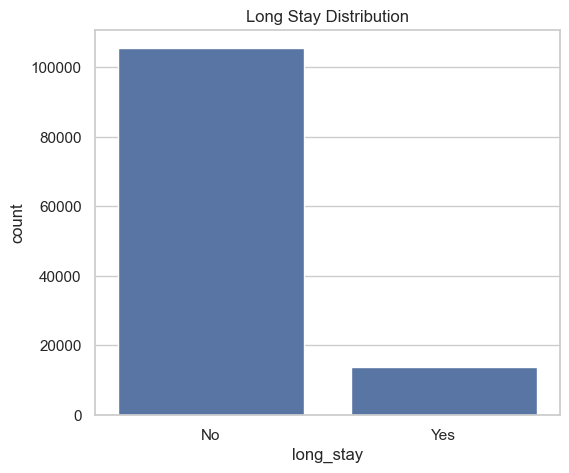

In [20]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="long_stay"
)

plt.title("Long Stay Distribution")

plt.show()

### Insight

Long-stay customers are valuable for revenue planning and loyalty strategies.

### Analysis 15: Booking Status by Hotel Type
Question

Which hotel has a higher cancellation rate?

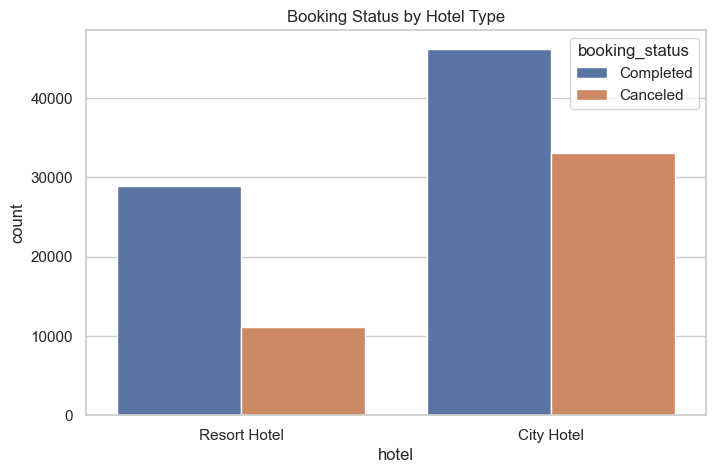

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="hotel",
    hue="booking_status"
)

plt.title("Booking Status by Hotel Type")

plt.show()

### Insight

Compare cancellation patterns across hotel types to identify operational challenges.

# Overall Business Insights

- City Hotels receive more bookings than Resort Hotels.
- Summer contributes significantly to tourism demand.
- Certain market segments dominate bookings.
- Advance bookings represent a large share of reservations.
- Family travelers and long-stay guests offer opportunities for targeted marketing.
- Booking cancellations should be monitored to reduce revenue loss.
- Seasonal demand can guide staffing and promotional campaigns.

In [22]:
df['adr'].isnull().sum()

np.int64(0)